In [3]:
import os
import sys
import re
from pathlib import Path
from multiprocessing import Pool
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde, skew, kurtosis

In [25]:
BASE_DIR = Path("/run/media/andres/2TB-Black/IDPAI/HPS1/Runs")
print(Path("/run/media/andres/2TB-Black/IDPAI/HPS1/Runs").exists())
OUTPUT_FILE = "idp_ml_dataset.parquet"  # Parquet format
NUM_CORES = os.cpu_count()
GRID_POINTS = np.linspace(0.0, 150, 450)

True


In [26]:
def parse_parameters(folder_path):
    """
    Parses the parameter block if it lives inside a file in the folder.
    Assumes it might be in config_stat.dat, a README, or a param file.
    Adjust the 'filename' below to wherever that text block lives.
    """
    param_file = folder_path / "System_Parameters.dat" 
    params = {}
    
    if not param_file.exists():
        return params
        
    try:
        with open(param_file, 'r') as f:
            content = f.read()
            
            # Regex to find key-value pairs (e.g., "Ionic concentration (M): 0.150000")
            # This extracts the numbers safely regardless of the exact text layout
            ionic = re.search(r"Ionic concentration.*:\s*([\d\.]+)", content)
            kappa = re.search(r"Yukawa kappa.*:\s*([\d\.]+)", content)
            epsilon = re.search(r"Yukawa epsilon.*:\s*([\d\.]+)", content)
            bjerrum = re.search(r"Bjerrum length.*:\s*([\d\.]+)", content)
            temp = re.search(r"Temperature.*:\s*([\d\.]+)", content)
            
            params['ionic_concentration_M'] = float(ionic.group(1)) if ionic else 0.15
            params['yukawa_kappa_nm_inv'] = float(kappa.group(1)) if kappa else 1.273787
            params['yukawa_epsilon_kcal_mol'] = float(epsilon.group(1)) if epsilon else 0.423234
            params['bjerrum_length_nm'] = float(bjerrum.group(1)) if bjerrum else 0.714697
            params['temperature_K'] = float(temp.group(1)) if temp else 298.0
    except Exception:
        # Fallback to defaults if parsing fails for a specific file
        pass
        
    return params

def process_single_folder(folder_path):
    """Worker function to completely parse a single simulation folder."""
    try:
        # 1. Read Sequence
        seq_file = folder_path / "OneLetterCode.dat"
        if not seq_file.exists():
            return None
        with open(seq_file, 'r') as f:
            sequence = "".join([line.strip() for line in f if line.strip()])

        # 2. Read config_stat.dat metrics
        config_file = folder_path / "config_stat.dat"
        config_data = np.loadtxt(config_file, comments="#")
        if config_data.ndim > 1: 
            config_data = config_data[0] # Fallback if multiple rows exist
            
        particle_n = int(config_data[0])
        persistence_length = config_data[2]  # <Lp>
        r_end_sq = config_data[3]            # <Rend2>
        avg_rg_config = config_data[4]       # <Rg>

        # 3. Read running_stat.dat (All Rg frames)
        running_file = folder_path / "running_stat.dat"
        rg_values = np.loadtxt(running_file, comments="#", usecols=2)
        if rg_values.ndim == 0:
            rg_values = np.array([rg_values])

        # 4. Statistical Moments of the Distribution
        total_frames = len(rg_values)
        rg_mean = np.mean(rg_values)
        rg_std = np.std(rg_values)
        rg_skew = skew(rg_values)
        rg_kurt = kurtosis(rg_values)

        # 5. Kernel Density Estimation (The Distogram)
        kde = gaussian_kde(rg_values)
        kde_distogram = kde.evaluate(GRID_POINTS)

        # 6. Parse Environmental Constants
        env_params = parse_parameters(folder_path)

        # 7. Combine everything into a master dictionary
        result = {
            "folder_id": folder_path.name,
            "sequence": sequence,
            "seq_length": particle_n,
            "persistence_length_lp": persistence_length,
            "mean_r_end_sq": r_end_sq,
            "config_avg_rg": avg_rg_config,
            "total_frames": total_frames,
            "calculated_rg_mean": rg_mean,
            "calculated_rg_std": rg_std,
            "calculated_rg_skew": rg_skew,
            "calculated_rg_kurtosis": rg_kurt,
            "rg_distogram": kde_distogram.tolist(),  # Must be list for Pandas -> Parquet export
        }
        
        # Merge the environmental parameters into the dictionary
        result.update(env_params)
        return result

    except Exception as e:
        print(f"Error in folder {folder_path.name}: {e}", file=sys.stderr)
        return None

In [27]:

print("Scanning directories...")
all_folders = [f for f in BASE_DIR.iterdir() if f.is_dir() and f.name.isdigit()]
print(f"Found {len(all_folders)} folders to parse.")
names = [a.name for a in all_folders]
arr = np.array(names)
nums = arr.astype(int)
nums.sort()
print(nums)
print(nums.shape)


Scanning directories...
Found 4783 folders to parse.
[   1    2    3 ... 9697 9698 9699]
(4783,)


In [28]:
print(f"Spinning up {NUM_CORES} CPU processes...")
results = []

with Pool(processes=NUM_CORES) as pool:
    # Using imap_unordered + chunksize to efficiently manage memory over 10k directories
    for res in pool.imap_unordered(process_single_folder, all_folders, chunksize=15):
        if res is not None:
            results.append(res)
            
        if len(results) % 500 == 0 and len(results) > 0:
            print(f"Progress: Captured {len(results)} / {len(all_folders)} datasets...")            

print("Building Dataframe...")
df = pd.DataFrame(results)

df["folder_id"] = df["folder_id"].astype(int)
df = df.sort_values("folder_id").reset_index(drop=True)
print(f"Writing dataset to Parquet format -> {OUTPUT_FILE}")
# engine='pyarrow' handles the nested float arrays perfectly
df.to_parquet(OUTPUT_FILE, engine='pyarrow', index=False)
print("Extraction successful! 2TB processed and packed.")

Spinning up 20 CPU processes...
Progress: Captured 500 / 4783 datasets...
Progress: Captured 1000 / 4783 datasets...


/tmp/ipykernel_58887/521179631.py:48: UserWarning: loadtxt: input contained no data: "/run/media/andres/2TB-Black/IDPAI/HPS1/Runs/2233/config_stat.dat"
  config_data = np.loadtxt(config_file, comments="#")
Error in folder 2233: index 0 is out of bounds for axis 0 with size 0


Progress: Captured 1500 / 4783 datasets...
Progress: Captured 2000 / 4783 datasets...
Progress: Captured 2500 / 4783 datasets...
Progress: Captured 3000 / 4783 datasets...
Progress: Captured 3500 / 4783 datasets...


Error in folder 9015: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9015/config_stat.dat not found.
Error in folder 9071: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9071/config_stat.dat not found.
Error in folder 9072: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9072/config_stat.dat not found.
Error in folder 9031: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9031/config_stat.dat not found.
Error in folder 887: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/887/running_stat.dat not found.
Error in folder 890: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/890/running_stat.dat not found.
Error in folder 9005: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9005/config_stat.dat not found.
Error in folder 9080: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9080/config_stat.dat not found.
Error in folder 9065: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9065/config_stat.dat not found.
Error in folder 9025: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9025/config_stat.dat not found.
Error in folder 9115: 

Progress: Captured 4000 / 4783 datasets...


Error in folder 9212: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9212/config_stat.dat not found.
Error in folder 9282: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9282/config_stat.dat not found.
Error in folder 9323: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9323/config_stat.dat not found.
Error in folder 9325: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9325/config_stat.dat not found.
Error in folder 9180: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9180/config_stat.dat not found.
Error in folder 9405: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9405/config_stat.dat not found.
Error in folder 9463: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9463/config_stat.dat not found.
Error in folder 9238: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9238/config_stat.dat not found.
Error in folder 9437: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9437/config_stat.dat not found.
Error in folder 9266: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9266/config_stat.dat not found.
Error in folder 9412

Progress: Captured 4500 / 4783 datasets...


Error in folder 9676: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9676/config_stat.dat not found.
Error in folder 9691: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9691/config_stat.dat not found.
Error in folder 9664: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9664/config_stat.dat not found.
Error in folder 9638: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9638/config_stat.dat not found.
Error in folder 9614: /run/media/andres/2TB-Black/IDPAI/HPS1/Runs/9614/config_stat.dat not found.


Building Dataframe...
Writing dataset to Parquet format -> idp_ml_dataset.parquet
Extraction successful! 2TB processed and packed.


Loading Parquet dataset...
Successfully loaded dataset with 4743 rows and 17 columns.

Exporting the first 5 rows to dataset_preview.csv...
CSV preview created! You can open this file to check your sequence/parameter alignments.

Generating histograms for the first few rows...
Plot saved successfully as 'idp_rg_distributions.png'!


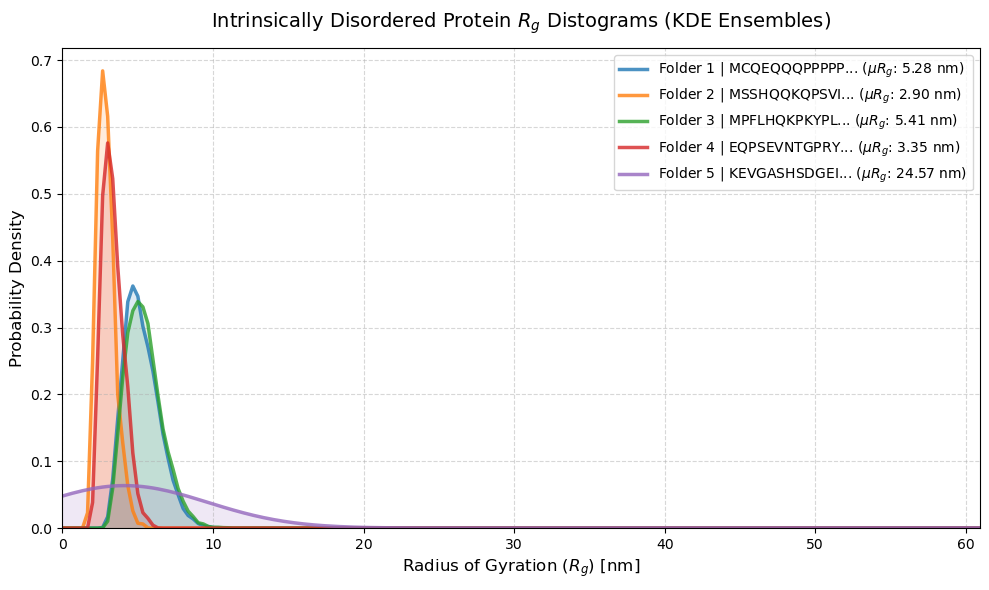

In [30]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
INPUT_FILE = "idp_ml_dataset.parquet"
CSV_SNIPPET_FILE = "dataset_preview.csv"

# Recreate the exact evaluation grid used during the parsing step
# (Make sure these match your parsing script settings: 0 to 30nm, 300 points)
def main():
    if not Path(INPUT_FILE).exists():
        print(f"Error: Could not find {INPUT_FILE} in the current directory.")
        return

    print("Loading Parquet dataset...")
    df = pd.read_parquet(INPUT_FILE)
    print(f"Successfully loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.")

    # ---------------------------------------------------------
    # PART 1: EXPORT A CLEAN CSV PREVIEW
    # ---------------------------------------------------------
    print(f"\nExporting the first 5 rows to {CSV_SNIPPET_FILE}...")
    
    # We take a slice of the first 5 rows
    df_preview = df.head(5).copy()
    
    # Crucial step: The 'rg_distogram' column holds a 300-element list. 
    # Storing this raw list makes the CSV messy. Let's truncate it to a string 
    # preview just for the CSV file so it's clean to look at.
    df_preview['rg_distogram'] = df_preview['rg_distogram'].apply(
        lambda x: f"[{x[0]:.4f}, {x[1]:.4f}, ..., {x[-1]:.4f}] (Len: {len(x)})"
    )
    
    # Save the preview snippet
    df_preview.to_csv(CSV_SNIPPET_FILE, index=False)
    print("CSV preview created! You can open this file to check your sequence/parameter alignments.")

    # ---------------------------------------------------------
    # PART 2: PLOT HISTOGRAMS (DISTOGRAM ENSEMBLES)
    # ---------------------------------------------------------
    print("\nGenerating histograms for the first few rows...")
    
    # Let's plot the first 3 sequences to see how their Rg distributions compare
    num_to_plot = min(5, len(df))
    
    plt.figure(figsize=(10, 6))
    
    for i in range(num_to_plot):
        row = df.iloc[i]
        folder_id = row['folder_id']
        sequence = row['sequence']
        mean_rg = row['calculated_rg_mean']
        
        # Grab the distogram vector
        distogram = np.array(row['rg_distogram'])
        
        # Shorten the sequence string if it's too long for the legend label
        seq_label = sequence if len(sequence) <= 15 else f"{sequence[:12]}..."
        
        # Plot the continuous density over our defined spatial grid
        plt.plot(
            GRID_POINTS, 
            distogram, 
            label=f"Folder {folder_id} | {seq_label} ($\mu R_g$: {mean_rg:.2f} nm)", 
            linewidth=2.5,
            alpha=0.8
        )
        
        # Fill the area under the curve for visual clarity
        plt.fill_between(GRID_POINTS, distogram, alpha=0.15)

    # Styling the plot for physical data
    plt.title("Intrinsically Disordered Protein $R_g$ Distograms (KDE Ensembles)", fontsize=14, pad=15)
    plt.xlabel("Radius of Gyration ($R_g$) [nm]", fontsize=12)
    plt.ylabel("Probability Density", fontsize=12)
    plt.xlim(0, max(df['calculated_rg_mean'].max(), 15.0)) # Dynamically scale X axis
    plt.ylim(bottom=0)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(fontsize=10, loc="upper right")
    plt.tight_layout()
    
    # Save and display
    plt.savefig("idp_rg_distributions.png", dpi=300)
    print("Plot saved successfully as 'idp_rg_distributions.png'!")
    plt.show()

if __name__ == "__main__":
    main()

Extremes plotted successfully! Saved as 'idp_rg_extremes.png'


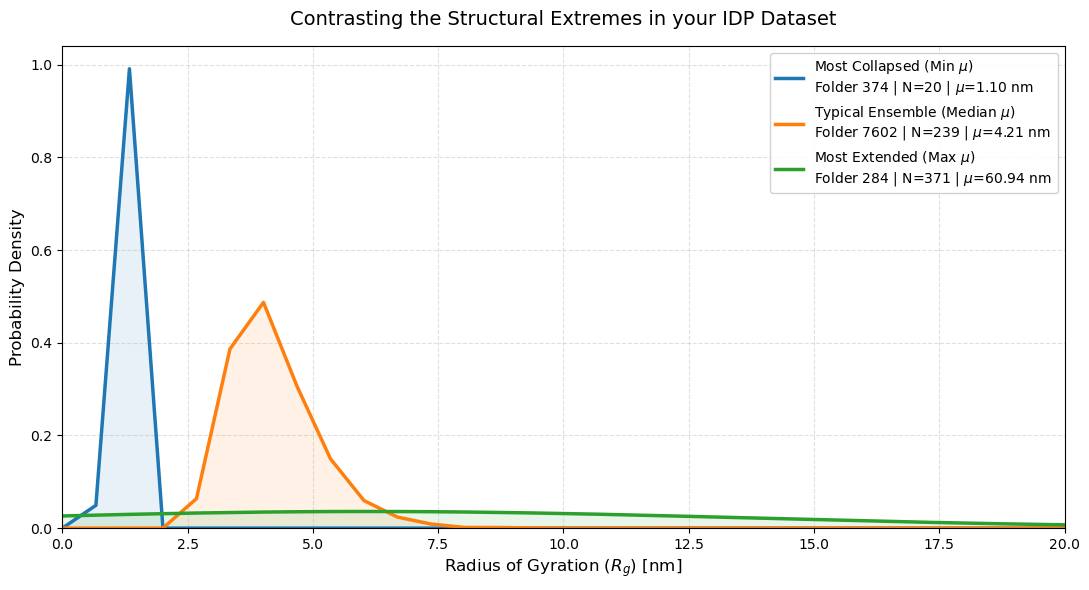

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt




# 1. Sort the dataframe by the calculated mean Rg to easily grab statistics
df_sorted = df.sort_values("calculated_rg_mean").reset_index(drop=True)

# 2. Extract the three target rows
row_min = df_sorted.iloc[0]                  # Lowest Mean Rg (Most Collapsed)
row_max = df_sorted.iloc[-1]                 # Highest Mean Rg (Most Extended)
row_mid = df_sorted.iloc[len(df_sorted) // 2] # Median Mean Rg (The Average Joes)


# Put them in a dictionary for easy looping
extremes = {
    "Most Collapsed (Min $\mu$)": row_min,
    "Typical Ensemble (Median $\mu$)": row_mid,
    "Most Extended (Max $\mu$)": row_max
}

# 3. Plotting
GRID_POINTS = np.linspace(0.0,200, 300) 
plt.figure(figsize=(11, 6))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"] # Clean contrasting colors

for (label, row), color in zip(extremes.items(), colors):
    folder_id = row['folder_id']
    seq_len = row['seq_length']
    mean_rg = row['calculated_rg_mean']
    distogram = np.array(row['rg_distogram'])
    
    # Format a clean legend label
    legend_text = f"{label}\nFolder {folder_id} | N={seq_len} | $\mu$={mean_rg:.2f} nm"
    
    # Plot the line
    plt.plot(GRID_POINTS, distogram, label=legend_text, color=color, linewidth=2.5)
    plt.fill_between(GRID_POINTS, distogram, color=color, alpha=0.1)

# Styling
plt.title("Contrasting the Structural Extremes in your IDP Dataset", fontsize=14, pad=15)
plt.xlabel("Radius of Gyration ($R_g$) [nm]", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)

# Dynamic X-axis limit based on the maximum Rg found
plt.xlim(0, 20)
plt.ylim(bottom=0)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(fontsize=10, loc="upper right", framealpha=0.9)
plt.tight_layout()

# Save the high-contrast plot
plt.savefig("idp_rg_extremes.png", dpi=300)
print("Extremes plotted successfully! Saved as 'idp_rg_extremes.png'")
plt.show()

In [36]:
# Load your full parsed dataset
df = pd.read_parquet("idp_ml_dataset.parquet")
target_seq = "ATSTKKLHKEPATLIKAIDGDTVKLMYKGQPMTFRLLLVDTPETKHPKKGVEKYGPEASAFTKKMVENAKKIEVEFDKGQRTDKYGRGLAYIYADGKMVNEALVRQGLAKVAYVYKPNNTHEQHLRKSEAQAKKEK" # Put the full string here

# Filter the DataFrame
asyn = df[df['sequence'] == target_seq]
if not asyn.empty:
    print(f"Found sequence in Folder: {asyn['folder_id'].values[0]}")
    print(asyn)
else:
    print("Sequence not found in the dataset.")

Sequence not found in the dataset.
